## HW 2 Part 2 - Drug Deaths

### 1)	Getting started
- Import the data from the csv file.  
- Investigate it using pandas’ `info` command. 
- What is the data type of the Date column?

In [1]:
import pandas as pd
df = pd.read_csv('drugdeaths.csv')
df.head()

,CaseNumber,Date,Sex,Race,Age,Residence City,Residence State,Residence County,Death City,Death State,...,Benzodiazepine,Methadone,Amphet,Tramad,Morphine (not heroin),Other,Any Opioid,MannerofDeath,AmendedMannerofDeath,DeathLoc
0,13-16336,11/9/13,Female,White,53.0,GROTON,NaN,NEW LONDON,GROTON,NaN,...,Y,NaN,NaN,NaN,NaN,NaN,NaN,Accident,NaN,"GROTON, CT\n(41.343693, -72.07877)"
1,12-18447,12/29/12,Male,White,30.0,WOLCOTT,NaN,NEW HAVEN,WATERBURY,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Accident,NaN,"WATERBURY, CT\n(41.554261, -73.043069)"
2,14-2758,2/18/14,Male,White,43.0,ENFIELD,NaN,NaN,ENFIELD,NaN,...,Y,NaN,NaN,NaN,NaN,NaN,NaN,Accident,NaN,"ENFIELD, CT\n(41.976501, -72.591985)"
3,14-13497,9/7/14,Female,White,24.0,WALLINGFORD,NaN,NaN,WALLINGFORD,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Accident,NaN,"WALLINGFORD, CT\n(41.454408, -72.818414)"
4,13-14421,10/4/13,Female,White,26.0,WEST HAVEN,NaN,NEW HAVEN,WEST HAVEN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Accident,NaN,"WEST HAVEN, CT\n(41.272336, -72.949817)"


In [2]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 3581 entries, 0 to 3580
Data columns (total 32 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   CaseNumber             3581 non-null   str    
 1   Date                   3581 non-null   str    
 2   Sex                    3579 non-null   str    
 3   Race                   3572 non-null   str    
 4   Age                    3580 non-null   float64
 5   Residence City         3490 non-null   str    
 6   Residence State        1663 non-null   str    
 7   Residence County       2885 non-null   str    
 8   Death City             3579 non-null   str    
 9   Death State            1702 non-null   str    
 10  Death County           2405 non-null   str    
 11  Location               3561 non-null   str    
 12  DescriptionofInjury    998 non-null    str    
 13  InjuryPlace            3504 non-null   str    
 14  ImmediateCauseA        3579 non-null   str    
 15  Heroin         

**The data column has `string` data type.**

### 2)	Reimport the data but this time add the argument `parse_dates = ['Date']`.
### Has the data type of the Date column changed?  If so, to what?

In [3]:
df = pd.read_csv('drugdeaths.csv', parse_dates = ['Date'])

C:\Users\ifrommer\AppData\Local\Temp\ipykernel_26780\2247979404.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df = pd.read_csv('drugdeaths.csv', parse_dates = ['Date'])


**Below is a snippet of `df.info()`. We can see that the Date column changed from type `string` to `datetime64[us]`**

```  
---  ------                 --------------  -----         
 0   CaseNumber             3581 non-null   str           
 1   Date                   3581 non-null   datetime64[us]
 ```

### 3)	Explain how you think the parse_dates argument works.

**Answer:  it tells `pandas` to process the column(s) passed to it as dates, converting to a `datetime` data type for easy processing as dates/times.**
<br>  <br>  <br>  

### 4)	The command `df['Date'].dt.month` will return a Series with the month number of the corresponding date. 
### Use this to create a new column in the DataFrame named “Month” and show that it was created.

We will show a snippet of the DataFrame showing the first few rows and a sample of columns including *Date* and the new *Month* column.

In [25]:
df['Month'] = df['Date'].dt.month
df.iloc[0:4][['Date','Age','Residence City','Death City','MannerofDeath','Month']]

,Date,Age,Residence City,Death City,MannerofDeath,Month
0,2013-11-09,53.0,GROTON,GROTON,Accident,11
1,2012-12-29,30.0,WOLCOTT,WATERBURY,Accident,12
2,2014-02-18,43.0,ENFIELD,ENFIELD,Accident,2
3,2014-09-07,24.0,WALLINGFORD,WALLINGFORD,Accident,9


### 5)	How many accidental drug deaths are there for each month in this dataset?  
#### Display your answer sorted by month order.
Hint: use the “MannerofDeath” column.

In [26]:
df['MannerofDeath'].value_counts()

MannerofDeath
Accident    3550
Pending       14
accident       9
Natural        1
ACCIDENT       1
Name: count, dtype: int64

Since we see multiple ways accident is written, but capture each one with `isin`.

In [27]:
df_accs = df[df['MannerofDeath'].isin(['Accident','ACCIDENT','accident'])]

In [28]:
df_accs['Month'].value_counts()

Month
6     350
3     327
2     326
5     324
1     319
4     314
11    303
10    288
12    275
7     249
9     248
8     237
Name: count, dtype: int64

**sort in month order -**

In [29]:
df_accs['Month'].value_counts().sort_index()

Month
1     319
2     326
3     327
4     314
5     324
6     350
7     249
8     237
9     248
10    288
11    303
12    275
Name: count, dtype: int64

###	6) What is the city with the most accidental deaths in this dataset?  How many deaths did this city have?

In [30]:
df_accs['Death City'].value_counts()

Death City
HARTFORD           364
NEW HAVEN          262
WATERBURY          251
BRIDGEPORT         226
NEW BRITAIN        151
                  ... 
KENT                 1
HAMPTON              1
BOLTON               1
NEW PRESTON          1
CORNWALL BRIDGE      1
Name: count, Length: 203, dtype: int64

In [31]:
df_accs['Death City'].value_counts().index[0]

'HARTFORD'

### 7)	Find the average age of accidental deaths for all cities in the dataset. 
Hint: start by using `groupby`

a.	What city has the oldest average age of accidental deaths?  What is the average age of accidental deaths for this city?

b.	What city has the youngest average age of accidental deaths?  What is the average age of accidental deaths for this city?

In [32]:
df_dc = df_accs.groupby(['Death City'])
dc_mean_age = df_dc['Age'].mean()

In [33]:
mean_age_sorted = dc_mean_age.sort_values()
mean_age_sorted

Death City
NEW PRESTON         17.0
STORRS              18.0
WARREN              21.0
EAST HARTLAND       21.0
WILTON              22.0
                    ... 
QUAKER HILL         58.0
SOUTHBURY           59.0
PLYMOUTH            60.0
VERNON-ROCKVILLE    62.0
GALES FERRY         65.0
Name: Age, Length: 203, dtype: float64

In [34]:
mean_age_sorted[:1]

Death City
NEW PRESTON    17.0
Name: Age, dtype: float64

In [35]:
mean_age_sorted[-1:]

Death City
GALES FERRY    65.0
Name: Age, dtype: float64

### 8)	Generate a bar chart to display the frequency of the ages that occur in this dataset. 
Note: this means for all ages found in the data set (not the city mean ages) and over all types of deaths (not just accidental)  
Hint: consider using the hist command and setting the number of bins using trial and error.  

<Axes: >

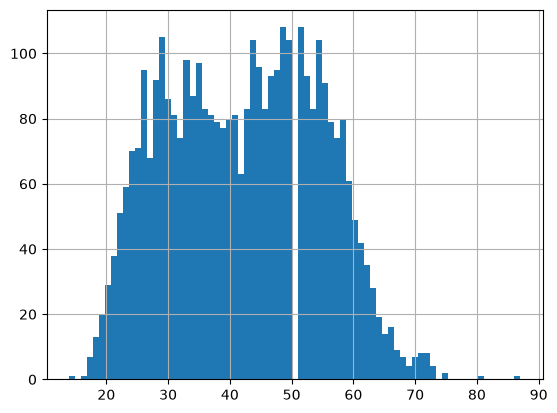

In [36]:
df['Age'].hist(bins=75)